In [2]:
import numpy as np
import pandas as pd

kategori_list = ["Elektronik", "Fashion", "Makanan & Minuman", "Kesehatan & Kecantikan", "Rumah Tangga"]
metode_bayar_list = ["Transfer Bank", "E-Wallet", "COD", "Kartu Kredit"]
tanggal_range = pd.date_range("2026-08-01", "2026-08-31", freq="D")

cabang_kota = {"Magelang": 101, "Yogyakarta": 202, "Semarang": 303}

for kota, seed in cabang_kota.items():
    np.random.seed(seed)
    n = 200
    data_cabang = {
        "order_id": [f"{kota[:3].upper()}-{2000 + i}" for i in range(n)],
        "tanggal": np.random.choice(tanggal_range, size=n),
        "kategori": np.random.choice(kategori_list, size=n, p=[0.25, 0.25, 0.20, 0.15, 0.15]),
        "unit_terjual": np.random.randint(1, 8, size=n),
        "harga_satuan": np.random.choice([25000, 50000, 75000, 100000, 150000, 250000], size=n),
        "metode_pembayaran": np.random.choice(metode_bayar_list, size=n),
    }
    df_cabang = pd.DataFrame(data_cabang)
    df_cabang["kota"] = kota
    nama_file = f"transaksi_{kota.lower()}.csv"
    df_cabang.to_csv(nama_file, index=False)
    print(f"Berkas '{nama_file}' berhasil dibuat: {df_cabang.shape[0]} baris")

Berkas 'transaksi_magelang.csv' berhasil dibuat: 200 baris
Berkas 'transaksi_yogyakarta.csv' berhasil dibuat: 200 baris
Berkas 'transaksi_semarang.csv' berhasil dibuat: 200 baris


In [5]:
!hdfs dfs -mkdir -p /user/azka/ecommerce/raw

In [6]:
!hdfs dfs -mkdir -p /user/azka/ecommerce/processed

In [7]:
!hdfs dfs -ls /user/azka/ecommerce

Found 3 items
drwxr-xr-x   - azka supergroup          0 2026-09-09 23:01 /user/azka/ecommerce/processed
drwxr-xr-x   - azka supergroup          0 2026-09-09 23:00 /user/azka/ecommerce/raw
drwxr-xr-x   - azka supergroup          0 2026-09-09 23:01 /user/azka/ecommerce/raw!hdfs


In [8]:
!hdfs dfs -put transaksi_magelang.csv /user/azka/ecommerce/raw/
!hdfs dfs -put transaksi_yogyakarta.csv /user/azka/ecommerce/raw/
!hdfs dfs -put transaksi_semarang.csv /user/azka/ecommerce/raw/

In [9]:
!hdfs dfs -ls -h /user/azka/ecommerce/raw

Found 3 items
-rw-r--r--   1 azka supergroup     12.0 K 2026-09-09 23:03 /user/azka/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 azka supergroup     11.9 K 2026-09-09 23:03 /user/azka/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 azka supergroup     12.4 K 2026-09-09 23:03 /user/azka/ecommerce/raw/transaksi_yogyakarta.csv


In [11]:
import pandas as pd
import subprocess
import io

def read_hdfs_csv(hdfs_path):
    cmd = f"hdfs dfs -cat {hdfs_path}"
    output = subprocess.check_output(cmd, shell=True)
    return pd.read_csv(io.BytesIO(output))

df_magelang = read_hdfs_csv("/user/azka/ecommerce/raw/transaksi_magelang.csv")
df_yogya = read_hdfs_csv("/user/azka/ecommerce/raw/transaksi_yogyakarta.csv")
df_semarang = read_hdfs_csv("/user/azka/ecommerce/raw/transaksi_semarang.csv")

df_gabungan = pd.concat([df_magelang, df_yogya, df_semarang], ignore_index=True)

print("Frekuensi transaksi di setiap kota:")
print(df_gabungan["kota"].value_counts())

Frekuensi transaksi di setiap kota:
kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64


In [12]:
df_gabungan["total_pendapatan"] = df_gabungan["unit_terjual"] * df_gabungan["harga_satuan"]

In [13]:
df_ringkasan = df_gabungan.groupby(["kota", "kategori"])["total_pendapatan"].sum().reset_index()

In [14]:
df_gabungan.to_csv("data_gabungan_bersih.csv", index=False)
df_ringkasan.to_csv("ringkasan_kota_kategori.csv", index=False)

In [15]:
!hdfs dfs -put data_gabungan_bersih.csv /user/azka/ecommerce/processed/
!hdfs dfs -put ringkasan_kota_kategori.csv /user/azka/ecommerce/processed/

In [16]:
!hdfs dfs -ls -h /user/azka/ecommerce/processed

Found 2 items
-rw-r--r--   1 azka supergroup     40.3 K 2026-09-09 23:06 /user/azka/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 azka supergroup        530 2026-09-09 23:06 /user/azka/ecommerce/processed/ringkasan_kota_kategori.csv


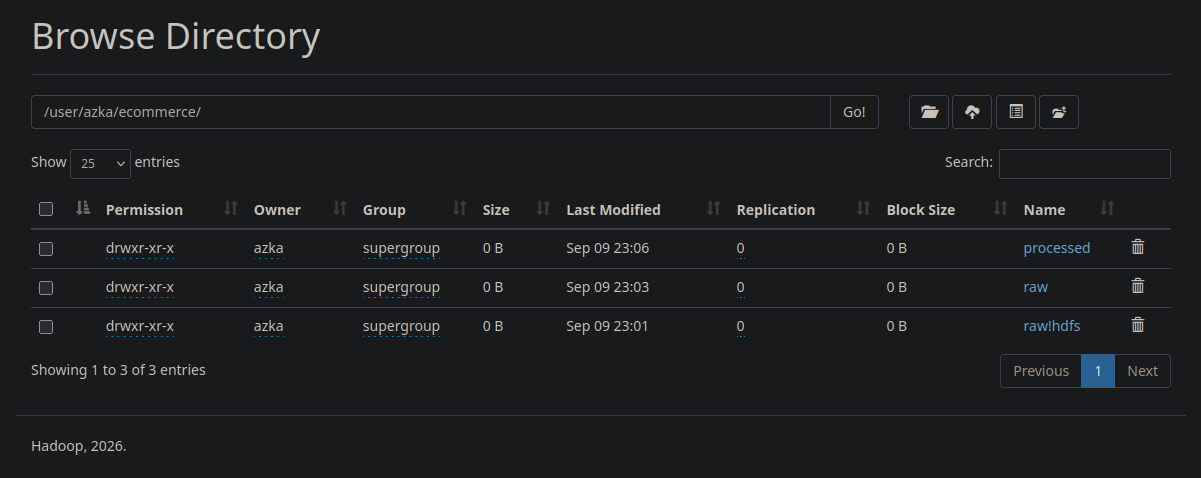